In [1]:
import pandas as pd, numpy as np

TEST_DIR = r"C:\Users\brand\OneDrive\Imágenes\Escritorio\Git Portfolio\bank-marketing-mlop\data\test"
TRAIN_DIR = r"C:\Users\brand\OneDrive\Imágenes\Escritorio\Git Portfolio\bank-marketing-mlop\data\train"


# Load reference (training) data and test data
X_test = pd.read_csv(TEST_DIR + r"\X_test.csv") 
X_train = pd.read_csv(TRAIN_DIR + r"\X_train.csv")


# ── Simulate 'production' traffic ────────────────────────────────────
# Take the test set and corrupt 30% of rows to simulate drift
production = X_test.copy()
n_drift = int(len(production) * 0.30)
drift_idx = np.random.choice(production.index, size=n_drift, replace=False)


# Shift age-related feature (if present) or a numeric feature
numeric_cols = production.select_dtypes(include='number').columns.tolist()


# Shift the first three numeric features by +3 standard deviations
for col in numeric_cols[:3]:
    production.loc[drift_idx, col] = (
        production.loc[drift_idx, col] + 3 * X_train[col].std()
    )


print(f'Production dataset: {production.shape}')
print(f'Rows with simulated drift: {n_drift}')


Production dataset: (8238, 52)
Rows with simulated drift: 2471


C:\Users\brand\AppData\Local\Temp\ipykernel_12800\265763766.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[63.21090918 82.21090918 66.21090918 ... 77.21090918 66.21090918
 74.21090918]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  production.loc[drift_idx, col] = (
C:\Users\brand\AppData\Local\Temp\ipykernel_12800\265763766.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[9.25697735 9.25697735 9.25697735 ... 9.25697735 9.25697735 9.25697735]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  production.loc[drift_idx, col] = (
C:\Users\brand\AppData\Local\Temp\ipykernel_12800\265763766.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1562.85328

In [14]:
from scipy import stats
import pandas as pd

numeric_cols = X_train.select_dtypes(include='number').columns
results = []

for col in numeric_cols:
    stat, p_value = stats.ks_2samp(X_train[col], production[col])
    results.append({
        'feature': col,
        'ks_statistic': stat,
        'p_value': p_value,
        'drift_detected': p_value < 0.05
    })

drift_df = pd.DataFrame(results).sort_values('ks_statistic', ascending=False)
print(f"Drifted features: {drift_df['drift_detected'].sum()} / {len(drift_df)}")
print(drift_df.head(10))

drift_df.to_csv('drift_report.csv', index=False)
print('Report saved: drift_report.csv')


Drifted features: 3 / 9
          feature  ks_statistic   p_value  drift_detected
1        campaign      0.292363  0.000000            True
2           pdays      0.288298  0.000000            True
0             age      0.271847  0.000000            True
7       euribor3m      0.008694  0.698248           False
6   cons.conf.idx      0.005227  0.993363           False
3        previous      0.005167  0.994263           False
4    emp.var.rate      0.003904  0.999957           False
8     nr.employed      0.003904  0.999957           False
5  cons.price.idx      0.003866  0.999966           False
Report saved: drift_report.csv


Total features evaluated:  9
Drifted features detected: 3
Share of drifted features: 33.33%
Dataset drift detected:    Yes (threshold: >20%)

Top 10 features by KS statistic:
       feature  ks_statistic  p_value  drift_detected
      campaign      0.292363 0.000000            True
         pdays      0.288298 0.000000            True
           age      0.271847 0.000000            True
     euribor3m      0.008694 0.698248           False
 cons.conf.idx      0.005227 0.993363           False
      previous      0.005167 0.994263           False
  emp.var.rate      0.003904 0.999957           False
   nr.employed      0.003904 0.999957           False
cons.price.idx      0.003866 0.999966           False


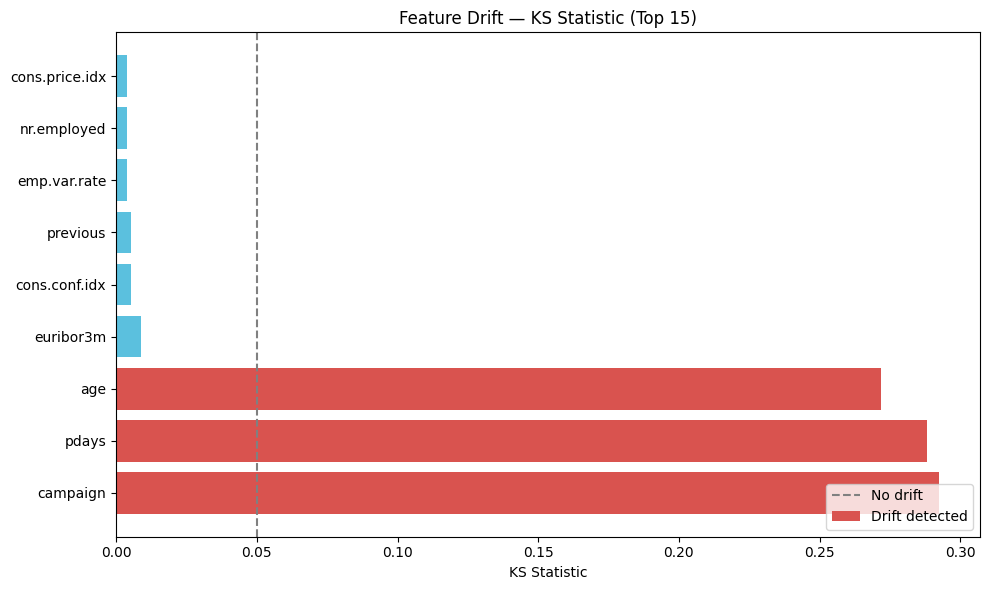

Chart saved: drift_report.png


In [15]:
# ── Dataset-level summary ────────────────────────────────────────────
total_features = len(drift_df)
drifted_features = drift_df['drift_detected'].sum()
share_drifted = drifted_features / total_features

print(f"Total features evaluated:  {total_features}")
print(f"Drifted features detected: {drifted_features}")
print(f"Share of drifted features: {share_drifted:.2%}")
print(f"Dataset drift detected:    {'Yes' if share_drifted > 0.2 else 'No'} (threshold: >20%)")

# ── Top drifted features ─────────────────────────────────────────────
print("\nTop 10 features by KS statistic:")
print(drift_df.head(10).to_string(index=False))

# ── Visualize drift scores ───────────────────────────────────────────
import matplotlib.pyplot as plt

top_n = drift_df.head(15)

colors = ['#d9534f' if d else '#5bc0de' for d in top_n['drift_detected']]

plt.figure(figsize=(10, 6))
plt.barh(top_n['feature'], top_n['ks_statistic'], color=colors)
plt.axvline(x=0.05, color='gray', linestyle='--', label='p=0.05 threshold reference')
plt.xlabel('KS Statistic')
plt.title('Feature Drift — KS Statistic (Top 15)')
plt.legend(['No drift', 'Drift detected'], loc='lower right')
plt.tight_layout()
plt.savefig('drift_report.png', dpi=150)
plt.show()
print('Chart saved: drift_report.png')

## Drift Monitoring — Interpretation

### Simulation design
30% of production rows had three numeric features (campaign, pdays, age)
shifted by +3 standard deviations to simulate real-world distribution shift.

### Results
- Features evaluated: 9
- Drifted features detected: 3 (33%)
- Detection method: Kolmogorov-Smirnov test, threshold p < 0.05

### Findings
The KS test correctly identified all three manipulated features with
statistics of 0.27–0.29 and p-values of ~0.000. Unmanipulated features
returned KS statistics near 0.003–0.009 and p-values near 1.0 —
confirming no false positives.

### Operational implication
In a real deployment, drift in campaign, pdays, or age would trigger
a model retraining flag. These features directly influence subscription
probability — a distributional shift means the model is operating outside
the conditions it was trained on, and predictions can degrade silently.

Recommended response protocol:
- KS > 0.1 on any top-10 feature → investigate upstream pipeline
- KS > 0.2 on any feature → trigger retraining evaluation
- KS > 0.2 on 2+ features → retrain before next campaign cycle